### OCI Data Science - Useful Tips
<details>
<summary><font size="2">Check for Public Internet Access</font></summary>

```python
import requests
response = requests.get("https://oracle.com")
assert response.status_code==200, "Internet connection failed"
```
</details>
<details>
<summary><font size="2">Helpful Documentation </font></summary>
<ul><li><a href="https://docs.cloud.oracle.com/en-us/iaas/data-science/using/data-science.htm">Data Science Service Documentation</a></li>
<li><a href="https://docs.cloud.oracle.com/iaas/tools/ads-sdk/latest/index.html">ADS documentation</a></li>
</ul>
</details>
<details>
<summary><font size="2">Typical Cell Imports and Settings for ADS</font></summary>

```python
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.ERROR)

import ads
from ads.dataset.factory import DatasetFactory
from ads.automl.provider import OracleAutoMLProvider
from ads.automl.driver import AutoML
from ads.evaluations.evaluator import ADSEvaluator
from ads.common.data import ADSData
from ads.explanations.explainer import ADSExplainer
from ads.explanations.mlx_global_explainer import MLXGlobalExplainer
from ads.explanations.mlx_local_explainer import MLXLocalExplainer
from ads.catalog.model import ModelCatalog
from ads.common.model_artifact import ModelArtifact
```
</details>
<details>
<summary><font size="2">Useful Environment Variables</font></summary>

```python
import os
print(os.environ["NB_SESSION_COMPARTMENT_OCID"])
print(os.environ["PROJECT_OCID"])
print(os.environ["USER_OCID"])
print(os.environ["TENANCY_OCID"])
print(os.environ["NB_REGION"])
```
</details>

## 0. Library Setup

- Install and Activate the Conda Pack: automlx251_p311_cpu_x86_64_v2

- Install the automlx package manually

In [ ]:
pip install oracle-automlx['classic']

- Basic setup for the Notebook. We will be running some magic commands to display matplotlib plots and to automatically reload modules



In [29]:
%load_ext autoreload
%autoreload 2
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load the required modules such as 
- gzip: compress/decompress files
- pandas: Accessing data
- numpy: Preprocessing data
- seaborn: Visualization
- matplotlib: Visualization
- sklearn: Mathematical Operations and other ML tasks

In [30]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score,confusion_matrix,make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [31]:
# Add settings for the Plots
plt.rcParams['figure.figsize']=[10,7]
plt.rcParams['font.size']= 15
sns.set(color_codes=True)
sns.set(font_scale=1.5)
sns.set_palette("bright")

Import and Initialize the AutoML Library

In [32]:
import automlx
from automlx import init

## 1. Loading the Adult Census Income Dataset 

Fetch the adult datase from OpenML

In [33]:
dataset=fetch_openml(name='adult',as_frame=True)
df,y =dataset.data,dataset.target

Get an overview of the data

In [34]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country
0,2,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States
1,3,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States
2,2,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States
3,3,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States
4,1,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba


A quick look at the data shows that it contains a mix of both Numerical and Text Data

## 1.1 Data Exploration

### 1.1.1 We also need to check for the data types of the columns

In [35]:
pd.DataFrame({'Data type': df.dtypes}).T

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country
Data type,category,category,float64,category,float64,category,category,category,category,category,category,category,category,category


### 1.1.2 Checking for Missing Values

In [36]:
pd.DataFrame({'% missing values': df.isnull().sum()*100 /len(df)}).T

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country
% missing values,0.0,5.730724,0.0,0.0,0.0,0.0,5.751198,0.0,0.0,0.0,0.0,0.0,0.0,1.754637


### 1.1.3 Visualizing the distribution of the target variable - Income

[Text(0, 0, '37155'), Text(0, 0, '11687')]

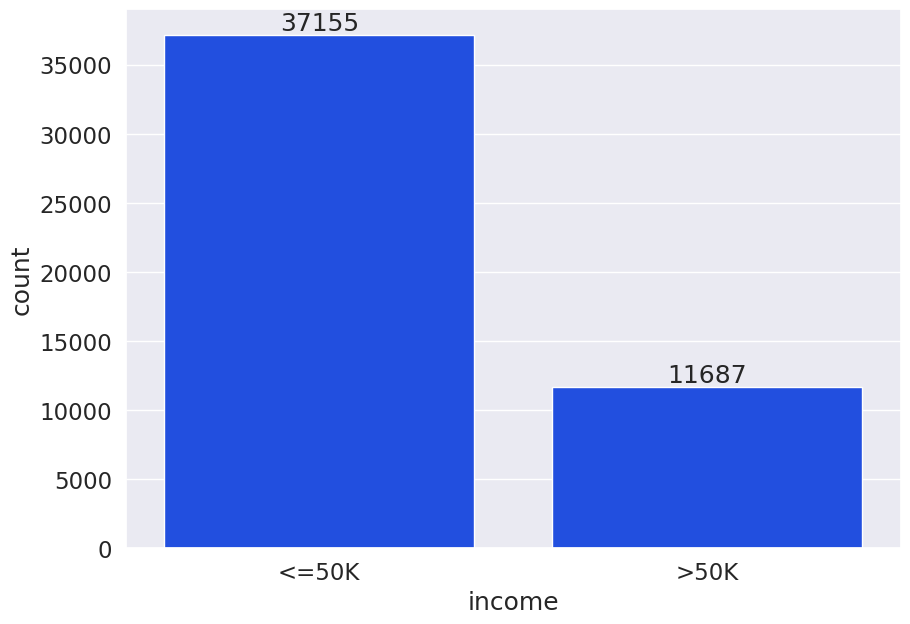

In [37]:
y_df=pd.DataFrame(y)
y_df.columns=['income']


ax=sns.countplot(x='income',data=y_df)
ax.bar_label(ax.containers[0])

## 1.2 Data Preprocessing

### 1.2.1 Fixing the data types

In [38]:
numeric_columns=['age','capitalgain','capitalloss','hoursperweek']

for col in df.columns:
    if col in numeric_columns:
        df[col]=df[col].astype(int)

### 1.2.2 Split the data into a train, test, validation with target field converted to a binary classification field

In [39]:
X_train,X_test,y_train,y_test=train_test_split(df,y.map({'>50K':1,'<=50K':0}).astype(int),train_size=0.7,random_state=0)

### 1.2.3 Inspect the Training set

In [40]:
X_train.shape,X_test.shape

((34189, 14), (14653, 14))

## 2. Apply AutoML 

### 2.0 Set the Engine 

In [41]:
init(engine='local')

### 2.1 Create an Instance of AutoMLX 

AutoMLX instance automatically finds a tuned model based on a prediction task and a given dataset. It contains the following modules
#### 1. <font color="blue">Preprocessing: </font>Data Cleaning, Data Imputation, Feature Engineering and Normalization </font> 
#### 2. <font color="blue">Algorithm Selection: </font>Identify the right classifiaction algorithm from the following: </font> 

- AdaBoostClassifier
- DecisionTreeClassifier
- ExtraTreesClassifier
- TorchMLPClassifier
- KNeighborsClassifier
- LGBMClassifier
- LinearSVC
- LogisticRegression
- RandomForestClassifier
- SVC
- XGBClassifier
- GaussianNB

#### 3. <font color="blue">Adaptive Sampling: </font>Selects a subset of the data for the model to be trained on and updates the sampling method based on the performance of the models
#### 4. <font color="blue">Feature Selection: </font>Select a subset of the data features based on the previously selected model 
#### 5. <font color="blue">Hyperparameter Tuning: </font>Finds the right model parameters to maximize score for the given dataset </font> 

All these modules are in the AutoML pipeline to automate the Machine Learning process with minimal user Input / Interaction


### 2.2 Train the Model Using AutoML

Initialize the automl pipeline, define the type of task and then fit the training data into the pipeline

In [42]:
est1=automlx.Pipeline(task='classification')
est1.fit(X_train,y_train)

[2025-11-22 04:05:38,497] [automlx.interface] Dataset shape: (34189,14)
[2025-11-22 04:05:38,595] [automlx.data_transform] Running preprocessing. Number of features: 15
[2025-11-22 04:05:39,221] [automlx.data_transform] Preprocessing completed. Took 0.627 secs
[2025-11-22 04:05:39,238] [automlx.process] Running Model Generation
[2025-11-22 04:05:39,274] [automlx] Provided model (TorchMLPClassifier) is not supported.Supported models are: ['CatBoostClassifier', 'LGBMClassifier', 'SVC', 'AdaBoostClassifier', 'DecisionTreeClassifier', 'ExtraTreesClassifier', 'GaussianNB', 'GradientBoostingClassifier', 'KNeighborsClassifier', 'LinearSVC', 'LogisticRegressionClassifier', 'RandomForestClassifier', 'XGBClassifier']
[2025-11-22 04:05:39,275] [automlx.process] KNeighborsClassifier is disabled. The KNeighborsClassifier model is only recommended for datasets with less than 10000 samples and 1000 features.
[2025-11-22 04:05:39,276] [automlx.process] SVC is disabled. The SVC model is only recommende

[04:06:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[2025-11-22 04:06:07,178] [automlx.model_selection] Model Selection completed - Took 27.830 sec - Selected models: [['XGBClassifier']]
[2025-11-22 04:06:07,220] [automlx.adaptive_sampling] Running Adaptive Sampling. Dataset shape: (34189,16).


[04:06:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:06:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_la

[2025-11-22 04:06:15,059] [automlx.trials] Adaptive Sampling completed - Took 7.8390 sec.
[2025-11-22 04:06:15,199] [automlx.feature_selection] Starting feature ranking for XGBClassifier


...

[2025-11-22 04:07:18,727] [automlx.feature_selection] Feature Selection completed. Took 63.560 secs.
[2025-11-22 04:07:18,763] [automlx.trials] Running Model Tuning for ['XGBClassifier']


[04:07:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:07:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[04:08:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_la

[2025-11-22 04:58:05,544] [automlx.trials] Best parameters for XGBClassifier: {'learning_rate': 0.1, 'min_child_weight': 2, 'max_depth': 3, 'reg_alpha': 0, 'booster': 'gbtree', 'reg_lambda': 1, 'n_estimators': 275, 'use_label_encoder': False}
[2025-11-22 04:58:05,547] [automlx.trials] Model Tuning completed. Took: 3046.784 secs
[2025-11-22 04:58:14,100] [automlx.interface] Re-fitting pipeline
[2025-11-22 04:58:14,117] [automlx.final_fit] Skipping updating parameter seed, already fixed by FinalFit_2c9c0428-c


[04:58:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[2025-11-22 04:58:16,447] [automlx.interface] AutoMLx completed.


A model est1 is now automatically generated. Using the model we can do the following:

### 2.2.1 Call its predict_proba method:
- Predicts the probability estimates for each class on the testing set X_test

In [46]:
y_proba=est1.predict_proba(X_test)

### 2.3 Evaluate Using AutoML

#### 2.3.1 Using Sklearn

- We use the roc_auc_score metric to evaluate the performance of the prediction on the testing set X_test

In [44]:
score_default=roc_auc_score(y_test,y_proba[:,1])

In [45]:
print(f'Score on test data : {score_default}')

Score on test data : 0.9139707190434818


#### 2.3.2 Using ADSEvaluator

In [ ]:
from ads.common.model import ADSModel
from ads.evaluations.evaluator import ADSEvaluator
from ads.common.data import ADSData

##### 2.3.2.1 Convert the model to ADS using ADSModel class

In [ ]:
selected_model_to_ads=ADSModel.from_estimator(est1,classes=[0,1])

In [ ]:
# Incase of multiclass classifier
#selected_model_to_ads=ADSModel.from_estimator(est1,classes=[0,1,2])

##### 2.3.2.2 Create an ADS evaluator from the converted model

In [ ]:
evaluator=ADSEvaluator(ADSData(X_test,y_test),models=[selected_model_to_ads],training_data=ADSData(X_train,y_train))

##### 2.3.2.3 Viewing all the metrics

In [ ]:
print(evaluator.metrics)

##### 2.3.2.4 Viewing all the charts

In [ ]:
evaluator.show_in_notebook(perfect=True)

Explain the model

In [ ]:
explainer=automlx.MLExplainer(est1,X_train,y_train,task="classification")

In [ ]:
explanation=explainer.explain_model()
explanation.to_dataframe()

# 2.4 Model Deployment

In [72]:
import ads
ads.set_auth(auth='resource_principal')
from ads.model import GenericModel
from ads.catalog.model import ModelCatalog
from ads.model.model_metadata import UseCaseType

## 2.4.1 Model Serialization

### 2.4.1.1 Initiate

In [68]:
artifacartifact_dir='/home/datascience/Acquiredskills_demos/Cloud_Development/Oracle_Cloud_Data_Science/serialized_models/automl_models'

In [69]:
print(f'Model artefact directory: {artifact_dir}')
automl_model=GenericModel(estimator=est1,artifact_dir=artifact_dir)

Model artefact directory: /home/datascience/Acquiredskills_demos/Cloud_Development/Oracle_Cloud_Data_Science/serialized_models/automl_models
[2025-11-22 05:22:55,272] [ads.common] In the future model input will be serialized by `cloudpickle` by default. Currently, model input are serialized into a dictionary containing serialized input data and original data type information.Set `model_input_serializer="cloudpickle"` to use cloudpickle model input serializer.


#### 2.4.1.1.1 Tracking the Serialization Process
We can track progress of our serialisation process using summary_status()

In [76]:
automl_model.summary_status()

Actions Needed
Step      Status        Details                                                           
initiate  Done          Initiated the model                                               
prepare() Done          Generated runtime.yaml                                            
                        Generated score.py                                                
                        Serialized model                                                  
          Available     Populated metadata(Custom, Taxonomy and Provenance)               
verify()  Not Available Local tested .predict from score.py                               
save()    Not Available Conducted Introspect Test                                         
                        Uploaded artifact to model catalog                                
deploy()  UNKNOWN       Deployed the model                                                
predict() Not Available Called deployment predict endpoint

### 2.4.1.2 Prepare

The prepare() method is used to prepare the model for deployment. It creates several customized files which include:
- input_schema.json - A JSON File which defines the nature of the features of the X_Sample. It includes metadata such as 
    - data type,name,constraints, summary statistics,feature_type
- model.h5: this is the default filename of the serialised model stored using the h5 file extension you can use the as_onnx to save it
- output_schema.json: A JSON File that defines the nature of the dependent variable in the y_sample data.It includes metadata such as 
    - data type,name,constraints, summary statistics,feature_type
- runtime.yaml: Contains information needed to setup the runtime environment on server. it contains information such as 
    -  Conda environment used for training, python version, and the deployment conda environment
- score.py: Contains
    -  load_model() function: Understands the format the model was saved in and loads it into memory.
    - predict() function: Used to make inferences from the model

In [87]:
conda_env='automlx251_p311_cpu_x86_64_v2'

automl_model.prepare(
    inference_conda_env=conda_env,
    training_conda_env=conda_env,
    use_case_type=UseCaseType.BINARY_CLASSIFICATION,
    X_sample=X_test,
    y_sample=y_test,
    force_overwrite=True
)

ERROR - Exception
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_16108/214261259.py", line 3, in <module>
    automl_model.prepare(
  File "/opt/conda/lib/python3.11/site-packages/ads/model/generic_model.py", line 1092, in prepare
    self.populate_metadata(
  File "/opt/conda/lib/python3.11/site-packages/ads/model/model_metadata_mixin.py", line 328, in populate_metadata
    self._populate_provenance_metadata(
  File "/opt/conda/lib/python3.11/site-packages/ads/model/model_metadata_mixin.py", line 245, in _populate_provenance_metadata
    ModelProvenanceMetadata.fetch_training_code_details(
  File "/opt/conda/lib/python3.11/site-packages/ads/model/model_metadata.py", line 1671, in fetch_training_code_details
    if repo.remotes.origin in repo.remotes
       ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-pa

### 2.4.1.3 Verify

if you make changes to the score.py file which is part of the model artefact, it should be verified.
 
This allows the code to be debugged without having to save the model to the catalog

The verify method takes a set of parameters and performs predictions by calling the predict() function

In [80]:
automl_model.verify(X_test[0:1],auto_serialize_data=True)

Start loading model.pkl from model directory /home/datascience/Acquiredskills_demos/Cloud_Development/Oracle_Cloud_Data_Science/serialized_models/automl_models ...
Model is successfully loaded.


{'prediction': [0]}

#### 2.4.1.3.1 Tracking the Serialization Process
We can track progress of our serialisation process using summary_status()

In [82]:
automl_model.summary_status()

Actions Needed
Step      Status        Details                                                           
initiate  Done          Initiated the model                                               
prepare() Done          Generated runtime.yaml                                            
                        Generated score.py                                                
                        Serialized model                                                  
          Available     Populated metadata(Custom, Taxonomy and Provenance)               
verify()  Done          Local tested .predict from score.py                               
save()    Not Available Conducted Introspect Test                                         
                        Uploaded artifact to model catalog                                
deploy()  UNKNOWN       Deployed the model                                                
predict() Not Available Called deployment predict endpoint

### 2.4.1.4 Save

This process saves the model to the model catalog and returns its OCID

In [83]:
model_id=automl_model.save(display_name='An AutoML Classifer for the Adult Income Dataset')

Start loading model.pkl from model directory /home/datascience/Acquiredskills_demos/Cloud_Development/Oracle_Cloud_Data_Science/serialized_models/automl_models ...
Model is successfully loaded.
['model.pkl', '.model-ignore', 'output_schema.json', 'input_schema.json', 'score.py', 'runtime.yaml']


loop1:   0%|          | 0/4 [00:00<?, ?it/s]

[2025-11-22 10:47:28,197] [ads.model.datascience_model] the JSON object must be str, bytes or bytearray, not Schema
[2025-11-22 10:47:28,198] [ads.model.datascience_model] the JSON object must be str, bytes or bytearray, not Schema


#### 2.4.1.4.1 Tracking the Serialization Process
We can track progress of our serialisation process using summary_status()

In [84]:
automl_model.summary_status()

Actions Needed
Step      Status        Details                                                           
initiate  Done          Initiated the model                                               
prepare() Done          Generated runtime.yaml                                            
                        Generated score.py                                                
                        Serialized model                                                  
          Available     Populated metadata(Custom, Taxonomy and Provenance)               
verify()  Done          Local tested .predict from score.py                               
save()    Done          Conducted Introspect Test                                         
                        Uploaded artifact to model catalog                                
deploy()  UNKNOWN       Deployed the model                                                
predict() Not Available Called deployment predict endpoint

### 2.3 Visualization of the AutoML Model Optimization Process 


During the AutoMl process the following information is logged
- Information about the training data
- Information about the AutoML Pipeline such as 
    - Most relevant features selected
    - Best choice Algorithm
    - Selected hyper parameters


#### 2.3.1 Summary Information for the AutoML Pipeline

In [ ]:
est1.print_summary()

#### 2.3.1 Visualization of the Summary Information for the AutoML Pipeline

##### 2.3.1.1 Algorithm Selection 

We can plot and visualize the results of the AutoML Algorithm Selection. Each Algorithm selection trial is a tuple containing
- Algorithm
- Number of Samples
- Number of Features
- Mean Cross Validation Score
- Hyperparameters
- All Cross Validation scores
- Total Cross Validation Times
- Memory Usage in GB

In [ ]:
trials = est1.completed_trials_summary_[
        est1.completed_trials_summary_["Step"].str.contains("Model Selection")
    ]


name_of_score_column = f"Score ({est1._inferred_score_metric[0].name})"
trials.replace([np.inf, -np.inf], np.nan, inplace=True)
trials.dropna(subset=[name_of_score_column], inplace=True)
scores = trials[name_of_score_column].tolist()
models = trials["Algorithm"].tolist()

y_margin=0.10*(max(scores)-min(scores))
s=pd.Series(scores,index=models).sort_values(ascending=False)

colors = []
for f in s.keys():
    if f.strip() == est1.selected_model_.strip():
        colors.append("orange")
    elif s[f] >= s.mean():
        colors.append("teal")
    else:
        colors.append("turquoise")


fig, ax = plt.subplots(1)
ax.set_title("Algorithm Selection Trials")
ax.set_ylim(min(scores) - y_margin, max(scores) + y_margin)
ax.set_ylabel("Hit Rate")
s.plot.bar(ax=ax, color=colors, edgecolor="black")
ax.axhline(y=s.mean(), color="black", linewidth=0.5)
plt.show()

##### 2.3.1.2 Selected Dataset Sample - Adaptive Sampling 

In [ ]:
trials = est1.completed_trials_summary_[
        est1.completed_trials_summary_["Step"].str.contains("Adaptive Sampling")
    ]

trials.replace([np.inf, -np.inf], np.nan, inplace=True)
trials.dropna(subset=[name_of_score_column], inplace=True)

scores=[x[3] for x in trials]
n_samples=[x[1] for x in trials]

y_margin=0.10*(max(scores)-min(scores))


fig,ax=plt.subplots(1)
ax.set_title('Adaptive Sampling({})'.format(trials[0][0]))
ax.set_xlabel('Dataset sample size')
ax.set_ylabel(est1._inferred_score_metric[0])
ax.grid(color='g',linestyle='-',linewidth=0.1)
ax.set_ylim(min(scores)-y_margin,max(scores)+y_margin)
ax.plot(n_samples,scores,'k:',markers='s',color='teal',markersize=3)
plt.show()

##### 2.3.1.3 Feature Selection 

In [ ]:
print(f'features selected:{est1.selected_features_names_}')
trials = est1.completed_trials_summary_[
        est1.completed_trials_summary_["Step"].str.contains("Adaptive Sampling")
    ]
est1.completed_trials_summary_

##### 2.3.1.4 Hyperparameter Tuning 

In [ ]:
trials = _pipeline.completed_trials_summary_[
        _pipeline.completed_trials_summary_["Step"].str.contains("Model Tuning")
    ]
    name_of_score_column = f"Score ({_pipeline._inferred_score_metric[0].name})"
    trials.replace([np.inf, -np.inf], np.nan, inplace=True)
    trials.dropna(subset=[name_of_score_column], inplace=True)
    trials.drop(trials[trials["Finished"] == -1].index, inplace=True)
    trials["Finished"] = trials["Finished"].apply(
        lambda x: time.mktime(datetime.datetime.strptime(x, "%a %b %d %H:%M:%S %Y").timetuple())
    )
    trials.sort_values(by=["Finished"], ascending=True, inplace=True)
    scores = trials[name_of_score_column].tolist()
    score = []
    score.append(scores[0])
    for i in range(1, len(scores)):
        if scores[i] >= score[i - 1]:
            score.append(scores[i])
        else:
            score.append(score[i - 1])
    y_margin = 0.10 * (max(score) - min(score))
    fig, ax = plt.subplots(1)
    ax.set_title("Hyperparameter Tuning Trials")
    ax.set_xlabel("Iteration $n$")
    ax.set_ylabel("Hit Rate")
    ax.grid(color="g", linestyle="-", linewidth=0.1)
    ax.set_ylim(min(score) - y_margin, max(score) + y_margin)
    ax.plot(range(1, len(trials) + 1), score, "k:", marker="s", color="teal", markersize=3)
    plt.show()

##### 2.3.1.5 Confusion Matrix HeatMap

In [ ]:
y_pred=est1.predict(X_test)
cm=confusion_matrix(y_test.astype(int),y_pred,labels=[False,True])
cm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]

df_cm=pd.DataFrame(cm)
df_cm=df_cm*100

ax=sns.heatmap(df_cm,annot=True,fmt='.2f',cbar=False,xticklabels=['<=50k','>50k'],yticklabels=['<=50k','>50k'])

ax.set_xlabel('Prediction')
ax.set_ylabel('Actual')

### 2.4 Customize AutoML Optimization Process 

#### 2.4.1 Provide a Specific Model List to AutoML 

AutoMLX allows for specification of a model or a combination of models based on the following algorithms:

- AdaBoostClassifier
- DecisionTreeClassifier
- ExtraTreesClassifier
- TorchMLPClassifier
- KNeighborsClassifier
- LGBMClassifier
- LinearSVC
- LogisticRegression
- RandomForestClassifier
- SVC
- XGBClassifier
- GaussianNB

In [ ]:
est2=automlx.Pipeline(model_list='LogisticRegression')
est2.fit(X_train,y_train)
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.2 Define a Custom Validation Set 

In [ ]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,train_size=0.7,random_state=0)

est3=automlx.Pipeline()
est3.fit(X_train,y_train,X_val,y_val)


In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.3 Increase the number of tuned models 

In [ ]:
est3=automlx.Pipeline(n_algos_tuned=2,model_list=['GausSianNB','LogisticRegression','DecisionTreeClassifier'])
est3.fit(X_train,y_train,X_val,y_val)

In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.3 Specify a Different Scoring Metric to AutoML 

The default score metrics for automlx are
- For classification: neg_log_loss
- For Regression: neg_mean_squared_error

The available metrics and charts to choose from are:
- For Binary Classification - Like 1 or 0
    - Metrics
        - roc_auc
        - accuracy
        - Hamming Loss
        - precision and its alternatives (micro,macro,weighted,samples)
        - recall and its alternatives (micro,macro,weighted,samples)
        - f1 and its alternatives (micro,macro,weighted,samples)
    - Charts
        - ROC Curve
        - Precision, Recall Curve
        - Lift Chart
        - Gain Chart
        - Confusion Matrix
- For Multiclass Classification - Discreet Data like Colours
    - Metrics
        - neg_log_loss
        - Hamming Loss
        - roc_auc
        - accuracy
        - precision and its alternatives (micro,macro,weighted,samples)
        - recall and its alternatives (micro,macro,weighted,samples)
        - f1 and its alternatives (micro,macro,weighted,samples)
    - Charts
        - Precision By Label
        - Recall By Label
        - ROC Curve
        - F1 By Label
        - Precision - Recall Curve
        - Confusion Matrix
        - Jaccard By Label
- For Regression - Continuous Data like Prices
    - Metrics
        - R - Squared
        - Explained Variance Score
        - Mean Squared Error
            - neg_mean_squared_error
            - neg_mean_squared_log_error
        - Root Mean Squared Error
        - Mean Absolute Error
            - neg_mean_absolute_error
        - neg_median_absolute_error
        - Mean Residuals
    - Charts
        - A plot of Actual Vs Predicted Values
        - A plot of Residuals Quantile - Quantile: should be close to a straight line
        - A plot of Residuals vs Predicted Values: should not have a good structure
        - A plot of Residuals vs Actual Values: should not have a good structure

In [ ]:
#specifying to automl to optimize the accuracy metric
est3=automlx.Pipeline(score_metric='accuracy',model_list=['GausSianNB','LogisticRegression','DecisionTreeClassifier'])
est3.fit(X_train,y_train,X_val,y_val)

In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.4 Specify a User Defined Scoring Function to AutoML 

In [ ]:
#Specifying a user defined score function using scikit learn model_scorer
score_fn=make_scorer(f1_score,greater_is_better=True,needs_proba=False,average=macro)
est3=automlx.Pipeline(score_metric=score_fn,model_list=['GausSianNB','LogisticRegression','DecisionTreeClassifier'])
est3.fit(X_train,y_train,X_val,y_val)

In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.5 Specify a time budget to AutoML 

In [ ]:
est3=automlx.Pipeline()
est3.fit(X_train,y_train,X_val,y_val,time_budget=10)

In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')

#### 2.4.6 Specify a Minimum Set of Features to AutoML 

In [ ]:
est3=automlx.Pipeline(min_features=['fnlwgt','native-country'])
est3.fit(X_train,y_train,X_val,y_val,time_budget=10)

In [ ]:
y_proba=est2.predict_proba(X_test)
score_default=roc_auc_score(y_test,y_proba[:,1])
print(f'Score on test data : {score_default}')
print(f'Selected Features : {est3.selected_feature_names_}')

# References 

Examples: https://automl.oraclecorp.com

Oracle AutoML: https://www.vldb.org/pvldb/vol13/p3166-yakovlev.pdf

Interpretable Machine Learning: https://christophm.github.io/interpretable-ml-book